In [15]:
import pandas as pd
df = pd.read_csv('dataset2.csv') # Your original MPU6050 data
cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'vib']


import pandas as pd
import numpy as np

# Load your original data (MPU6050 readings)
df = pd.read_csv('dataset2.csv') 
cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'vib']

# ANALYSIS: Calculate the baseline thresholds
analysis = df[cols].agg(['mean', 'std'])

print("--- Baseline Thresholds (Normal State) ---")
for col in cols:
    mean_val = analysis.loc['mean', col]
    std_val = analysis.loc['std', col]
    print(f"{col:4} | Mean: {mean_val:8.4f} | Noise Threshold (Std): {std_val:8.4f}")

# The 'vibration_multiplier' defines the boundary between Normal and Faulty
# Usually, a 2x to 3x increase in Std Dev is the threshold for a 'Fault'
vibration_multiplier = 4.5

--- Baseline Thresholds (Normal State) ---
ax   | Mean:   0.9608 | Noise Threshold (Std):   0.2827
ay   | Mean:   0.0044 | Noise Threshold (Std):   0.1115
az   | Mean:  -0.1680 | Noise Threshold (Std):   0.3171
gx   | Mean:  -0.1984 | Noise Threshold (Std):  10.0112
gy   | Mean:   6.6219 | Noise Threshold (Std):  38.4901
gz   | Mean:   0.9139 | Noise Threshold (Std):   8.8679
vib  | Mean:   1.0398 | Noise Threshold (Std):   0.2505


In [16]:
def generate_replicated_data(num_samples, is_faulty=False):
    generated_data = pd.DataFrame()
    multiplier = 4.5 if is_faulty else 1.0
    
    for col in cols:
        m = analysis.loc['mean', col]
        s = analysis.loc['std', col]
        
        # We generate values using the exact 'DNA' of your original data
        # For faulty data, we expand the threshold (s)
        generated_data[col] = np.random.normal(loc=m, scale=s * multiplier, size=num_samples)
    
    generated_data['label'] = 1 if is_faulty else 0
    return generated_data

# Create 10,000 rows of each to make a 20,000 row dataset
df_normal = generate_replicated_data(1000000, is_faulty=False)
df_faulty = generate_replicated_data(1000000, is_faulty=True)

# Final Merge
df_perfect = pd.concat([df_normal, df_faulty], ignore_index=True).sample(frac=1)
df_perfect.to_csv('mpu6050_perfect_replicated.csv', index=False)

In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Load Your Data ---
# Assuming your dataset is named 'dataset2.csv'
df = pd.read_csv('C:/Users/USER/MPU5060_1DCNN_MODEL/mpu6050_perfect_replicated.csv')

# Select features: ax, ay, az, gx, gy, gz, vib
features = ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'vib']
X = df[features].values
y = df['label'].values

# --- Windowing Function ---
def create_windows(X, y, window_size=100, step_size=50):
    X_windows = []
    y_windows = []
    for i in range(0, len(X) - window_size, step_size):
        X_windows.append(X[i:i + window_size])
        # Use the most common label in the window
        y_windows.append(np.bincount(y[i:i + window_size]).argmax())
    return np.array(X_windows), np.array(y_windows)

# Create 100-sample windows (approx 0.1s to 0.2s of data based on your timestamps)
X_win, y_win = create_windows(X, y, window_size=100, step_size=50)

# Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X_win, y_win, test_size=0.2, random_state=42)

In [19]:
def create_motor_model(input_shape, num_classes):
    model = tf.keras.models.Sequential([
        # Input: Window of 500 samples, 7 features (ax, ay, az, gx, gy, gz, vib)
        tf.keras.layers.Input(shape=input_shape), 
        
        # CNN Layers extract the "DNA" of the vibration
        tf.keras.layers.Conv1D(64, kernel_size=7, activation='relu'),
        tf.keras.layers.BatchNormalization(), # Added for stability
        tf.keras.layers.MaxPooling1D(2),
        
        tf.keras.layers.Conv1D(128, kernel_size=5, activation='relu'),
        tf.keras.layers.GlobalAveragePooling1D(), # Flattens wave to features
        
        # Dense layers for the final decision
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3), 
        tf.keras.layers.Dense(num_classes, activation='softmax') 
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 1. Define your shapes correctly
# X_train.shape[1] is window size (e.g., 500), X_train.shape[2] is features (7)
my_input_shape = (X_train.shape[1], X_train.shape[2]) 
my_num_classes = len(np.unique(y_win))

# 2. Call the FUNCTION to create the model
model = create_motor_model(my_input_shape, my_num_classes)

# 3. Now summary will work perfectly
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 94, 64)         │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 94, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 43, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,930 (206.76 KB)

 Trainable params: 52,802 (206.26 KB)

 Non-trainable params: 128 (512.00 B)

In [20]:
# Train the model
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.1)

# Evaluate on unseen data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save for your GUI or Real-time detection
model.save('mpu6050_motor_model.h5')

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6930 - loss: 0.5706 - val_accuracy: 0.7350 - val_loss: 0.5177
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7499 - loss: 0.5012 - val_accuracy: 0.7625 - val_loss: 0.4808
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7713 - loss: 0.4733 - val_accuracy: 0.7828 - val_loss: 0.4484
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7846 - loss: 0.4519 - val_accuracy: 0.7862 - val_loss: 0.4459
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7946 - loss: 0.4370 - val_accuracy: 0.7953 - val_loss: 0.4378
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7994 - loss: 0.4266 - val_accuracy: 0.7866 - val_loss: 0.4496
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8086 - loss: 0.4113 - val_accuracy: 0.7903 - val_loss: 0.4459
Epoch 8/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8118 - loss: 0.4068 - val_accuracy:

Test Accuracy: 77.50%


In [21]:
# Save the trained model
model_name = 'mpu6050_cnn_v1.h5'
model.save(model_name)
print(f"✅ Model saved as {model_name}")

# Save accuracy to a text file
with open('model_metrics.txt', 'w') as f:
    f.write(f"Final Test Accuracy: {test_acc*100:.2f}%\n")
    f.write(f"Final Test Loss: {test_loss:.4f}\n")

✅ Model saved as mpu6050_cnn_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


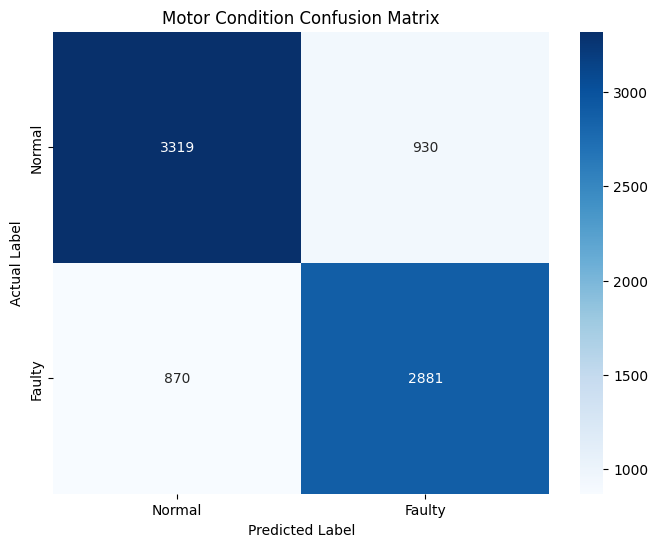


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.78      0.79      4249
           1       0.76      0.77      0.76      3751

    accuracy                           0.78      8000
   macro avg       0.77      0.77      0.77      8000
weighted avg       0.78      0.78      0.78      8000



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Faulty'], # Update these based on your labels
            yticklabels=['Normal', 'Faulty'])
plt.title('Motor Condition Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print detailed report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))